In [2]:
import pandas as pd
import numpy as np

# Load the dataset (update path if needed)
df = pd.read_csv('IMDB Dataset.csv')


In [3]:
# Basic info
print("Shape:", df.shape)
print("\nColumn names:", df.columns.tolist())
print("\nFirst 5 rows:")
print(df.head())

Shape: (50000, 2)

Column names: ['review', 'sentiment']

First 5 rows:
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


In [4]:
# Check class balance
print("\nClass distribution:")
print(df['sentiment'].value_counts())

# Check for nulls and duplicates
print("\nNull values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

# Review length stats (word count)
df['word_count'] = df['review'].apply(lambda x: len(x.split()))
print("\nWord count stats:")
print(df['word_count'].describe())


Class distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64

Null values:
 review       0
sentiment    0
dtype: int64

Duplicate rows: 418

Word count stats:
count    50000.000000
mean       231.156940
std        171.343997
min          4.000000
25%        126.000000
50%        173.000000
75%        280.000000
max       2470.000000
Name: word_count, dtype: float64


In [5]:
# Peek at one raw review to see formatting issues (HTML tags etc.)
print("\nSample raw review:\n")
print(df['review'].iloc[0])


Sample raw review:

One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the s

In [6]:
import re
import string

# --- Drop duplicates first ---
df = df.drop_duplicates(subset='review').reset_index(drop=True)
print("Shape after dropping duplicates:", df.shape)


Shape after dropping duplicates: (49582, 3)


In [7]:
# --- Text cleaning function ---
def clean_text(text):
    text = text.lower()                                  # lowercase
    text = re.sub(r'<.*?>', ' ', text)                    # remove HTML tags like <br />
    text = re.sub(r'http\S+|www\S+', ' ', text)           # remove URLs
    text = re.sub(r'[^a-z\s]', ' ', text)                 # remove punctuation/numbers, keep letters
    text = re.sub(r'\s+', ' ', text).strip()              # remove extra whitespace
    return text

df['cleaned_review'] = df['review'].apply(clean_text)


In [8]:
# Compare before/after on a sample
print("\n--- BEFORE ---")
print(df['review'].iloc[1][:300])
print("\n--- AFTER ---")
print(df['cleaned_review'].iloc[1][:300])


--- BEFORE ---
A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes discomforting, sense of realism to the entire piece. <br /><br />The actors are extremely well chosen- Michael Sheen not only "has got all the polari" 

--- AFTER ---
a wonderful little production the filming technique is very unassuming very old time bbc fashion and gives a comforting and sometimes discomforting sense of realism to the entire piece the actors are extremely well chosen michael sheen not only has got all the polari but he has all the voices down p


In [9]:
# Encode target labels: positive -> 1, negative -> 0
df['label'] = df['sentiment'].map({'positive': 1, 'negative': 0})
print("\nLabel mapping check:")
print(df[['sentiment', 'label']].drop_duplicates())


Label mapping check:
  sentiment  label
0  positive      1
3  negative      0


In [10]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

# Standard English stopwords
stop_words = set(stopwords.words('english'))

# Keep negation words - remove them from the stopword list
negation_words = {'not', 'no', 'nor', 'never', 'none', "n't", 'cannot', 
                   "don't", "doesn't", "didn't", "won't", "can't", "shouldn't",
                   "wouldn't", "isn't", "aren't", "wasn't", "weren't"}
stop_words = stop_words - negation_words

stemmer = PorterStemmer()

def preprocess_text(text):
    words = text.split()
    words = [w for w in words if w not in stop_words]   # remove stopwords (keep negations)
    words = [stemmer.stem(w) for w in words]             # stemming
    return ' '.join(words)

df['final_review'] = df['cleaned_review'].apply(preprocess_text)

# Compare all 3 stages on a sample
print("--- CLEANED (before stopword/stem) ---")
print(df['cleaned_review'].iloc[1][:300])
print("\n--- FINAL (after stopword removal + stemming) ---")
print(df['final_review'].iloc[1][:300])

# Check average word count reduction
df['final_word_count'] = df['final_review'].apply(lambda x: len(x.split()))
print("\nAvg word count before:", df['cleaned_review'].apply(lambda x: len(x.split())).mean())
print("Avg word count after:", df['final_word_count'].mean())

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Ananya\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


--- CLEANED (before stopword/stem) ---
a wonderful little production the filming technique is very unassuming very old time bbc fashion and gives a comforting and sometimes discomforting sense of realism to the entire piece the actors are extremely well chosen michael sheen not only has got all the polari but he has all the voices down p

--- FINAL (after stopword removal + stemming) ---
wonder littl product film techniqu unassum old time bbc fashion give comfort sometim discomfort sens realism entir piec actor extrem well chosen michael sheen not got polari voic pat truli see seamless edit guid refer william diari entri not well worth watch terrificli written perform piec master pr

Avg word count before: 234.36218789076682
Avg word count after: 119.97781452946634


In [11]:
from sklearn.model_selection import train_test_split

X = df['final_review']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y   # ensures 50/50 class balance is preserved in both sets
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTrain class distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest class distribution:")
print(y_test.value_counts(normalize=True))

Train shape: (39665,)
Test shape: (9917,)

Train class distribution:
label
1    0.501878
0    0.498122
Name: proportion, dtype: float64

Test class distribution:
label
1    0.501865
0    0.498135
Name: proportion, dtype: float64


In [12]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# --- Bag of Words (unigrams) ---
bow_vectorizer = CountVectorizer(max_features=10000, min_df=5, max_df=0.8)
X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow = bow_vectorizer.transform(X_test)

# --- TF-IDF (unigrams) ---
tfidf_vectorizer = TfidfVectorizer(max_features=10000, min_df=5, max_df=0.8)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

# --- TF-IDF with unigrams + bigrams ---
tfidf_bigram_vectorizer = TfidfVectorizer(max_features=15000, min_df=5, max_df=0.8, ngram_range=(1,2))
X_train_tfidf_bigram = tfidf_bigram_vectorizer.fit_transform(X_train)
X_test_tfidf_bigram = tfidf_bigram_vectorizer.transform(X_test)

print("BoW train shape:", X_train_bow.shape)
print("TF-IDF train shape:", X_train_tfidf.shape)
print("TF-IDF (uni+bi) train shape:", X_train_tfidf_bigram.shape)

# Peek at some feature names
print("\nSample BoW features:", bow_vectorizer.get_feature_names_out()[:20])
print("\nSample TF-IDF bigram features:", 
      [f for f in tfidf_bigram_vectorizer.get_feature_names_out() if ' ' in f][:10])

BoW train shape: (39665, 10000)
TF-IDF train shape: (39665, 10000)
TF-IDF (uni+bi) train shape: (39665, 15000)

Sample BoW features: ['aamir' 'aaron' 'ab' 'abandon' 'abba' 'abbey' 'abbi' 'abbot' 'abbott'
 'abc' 'abduct' 'abe' 'abid' 'abigail' 'abil' 'abl' 'abli' 'abnorm'
 'aboard' 'abomin']

Sample TF-IDF bigram features: ['abbott costello', 'abl get', 'abl make', 'abl see', 'abl watch', 'absolut brilliant', 'absolut hilari', 'absolut horribl', 'absolut love', 'absolut no']


In [13]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
import time

results = []

feature_sets = {
    'BoW': (X_train_bow, X_test_bow),
    'TF-IDF': (X_train_tfidf, X_test_tfidf),
    'TF-IDF (uni+bi)': (X_train_tfidf_bigram, X_test_tfidf_bigram)
}

models = {
    'Naive Bayes': MultinomialNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000)
}

for feat_name, (X_tr, X_te) in feature_sets.items():
    for model_name, model in models.items():
        start = time.time()
        model.fit(X_tr, y_train)
        preds = model.predict(X_te)
        
        acc = accuracy_score(y_test, preds)
        f1 = f1_score(y_test, preds)
        elapsed = time.time() - start
        
        results.append({
            'Feature': feat_name,
            'Model': model_name,
            'Accuracy': round(acc, 4),
            'F1-score': round(f1, 4),
            'Time (s)': round(elapsed, 2)
        })
        print(f"{feat_name} + {model_name}: Accuracy={acc:.4f}, F1={f1:.4f}, Time={elapsed:.2f}s")

results_df = pd.DataFrame(results)
print("\n\n=== FINAL COMPARISON TABLE ===")
print(results_df.sort_values('Accuracy', ascending=False))

BoW + Naive Bayes: Accuracy=0.8492, F1=0.8477, Time=0.08s
BoW + Logistic Regression: Accuracy=0.8711, F1=0.8721, Time=5.86s
TF-IDF + Naive Bayes: Accuracy=0.8571, F1=0.8575, Time=0.07s
TF-IDF + Logistic Regression: Accuracy=0.8921, F1=0.8939, Time=1.04s
TF-IDF (uni+bi) + Naive Bayes: Accuracy=0.8740, F1=0.8763, Time=0.07s
TF-IDF (uni+bi) + Logistic Regression: Accuracy=0.8991, F1=0.9007, Time=0.87s


=== FINAL COMPARISON TABLE ===
           Feature                Model  Accuracy  F1-score  Time (s)
5  TF-IDF (uni+bi)  Logistic Regression    0.8991    0.9007      0.87
3           TF-IDF  Logistic Regression    0.8921    0.8939      1.04
4  TF-IDF (uni+bi)          Naive Bayes    0.8740    0.8763      0.07
1              BoW  Logistic Regression    0.8711    0.8721      5.86
2           TF-IDF          Naive Bayes    0.8571    0.8575      0.07
0              BoW          Naive Bayes    0.8492    0.8477      0.08


              precision    recall  f1-score   support

    Negative       0.91      0.89      0.90      4940
    Positive       0.89      0.91      0.90      4977

    accuracy                           0.90      9917
   macro avg       0.90      0.90      0.90      9917
weighted avg       0.90      0.90      0.90      9917



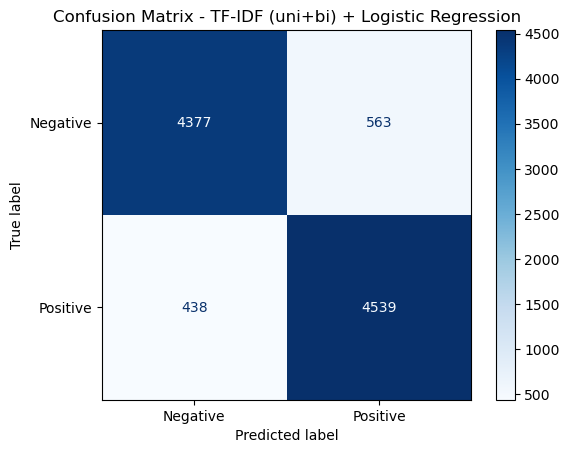


Total misclassified: 1001 out of 9917

--- Sample misclassified reviews ---

True: Positive | Predicted: Negative
exactli great film admir writer director tri someth littl differ film main theme fate small seemingli insignific thing greatli chang futur way remind film slide door though instead focus one random event seemingli random stuff happen repeatedli one h

True: Negative | Predicted: Positive
despit huge fan fred astair ginger roger movi year ago first saw follow fleet knew song old astair roger record ye vinyl knew noth plot unfortun song catchi ginger roger charact sweet funni like bake baker tri make longtim partner continu sabotag car

True: Negative | Predicted: Positive
know full moon film studio matter could never recaptur fun cheesi sci fi feel origin trancer last two entri seri jack deth mediev time instead futurist lo angel becam quit obviou realli littl hope reviv trancer seri breath new life film one thing tak

True: Positive | Predicted: Negative
well well roeg tou

In [14]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Retrain the best model explicitly (in case results_df loop overwrote 'model')
best_model = LogisticRegression(max_iter=1000)
best_model.fit(X_train_tfidf_bigram, y_train)
best_preds = best_model.predict(X_test_tfidf_bigram)

# Classification report
print(classification_report(y_test, best_preds, target_names=['Negative', 'Positive']))

# Confusion matrix
cm = confusion_matrix(y_test, best_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Positive'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - TF-IDF (uni+bi) + Logistic Regression')
plt.show()

# Look at some misclassified examples
X_test_reset = X_test.reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True)

misclassified_idx = np.where(best_preds != y_test_reset)[0]
print(f"\nTotal misclassified: {len(misclassified_idx)} out of {len(y_test_reset)}")

print("\n--- Sample misclassified reviews ---")
for i in misclassified_idx[:5]:
    print(f"\nTrue: {'Positive' if y_test_reset[i]==1 else 'Negative'} | Predicted: {'Positive' if best_preds[i]==1 else 'Negative'}")
    print(X_test_reset.iloc[i][:250])

In [15]:
feature_names = np.array(tfidf_bigram_vectorizer.get_feature_names_out())
coefs = best_model.coef_[0]

# Top positive and negative features
top_positive_idx = np.argsort(coefs)[-20:][::-1]
top_negative_idx = np.argsort(coefs)[:20]

print("=== Top 20 words/phrases pushing toward POSITIVE ===")
for idx in top_positive_idx:
    print(f"{feature_names[idx]:25s} : {coefs[idx]:.3f}")

print("\n=== Top 20 words/phrases pushing toward NEGATIVE ===")
for idx in top_negative_idx:
    print(f"{feature_names[idx]:25s} : {coefs[idx]:.3f}")

=== Top 20 words/phrases pushing toward POSITIVE ===
great                     : 7.422
excel                     : 6.973
perfect                   : 5.444
enjoy                     : 5.348
love                      : 4.903
best                      : 4.847
amaz                      : 4.707
fun                       : 4.356
brilliant                 : 4.311
favorit                   : 4.309
one best                  : 4.244
hilari                    : 4.144
must see                  : 4.030
today                     : 4.016
beauti                    : 3.934
well                      : 3.816
definit                   : 3.788
superb                    : 3.740
highli recommend          : 3.489
fantast                   : 3.455

=== Top 20 words/phrases pushing toward NEGATIVE ===
worst                     : -9.167
aw                        : -8.009
bad                       : -7.935
wast                      : -7.335
bore                      : -7.095
poor                      : -6.169
ter

In [16]:
# You need to retrain Naive Bayes on the same TF-IDF+bigram features to compare fairly
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf_bigram, y_train)

feature_names_nb = np.array(tfidf_bigram_vectorizer.get_feature_names_out())

# log P(word | positive) - log P(word | negative)
log_prob_diff = nb_model.feature_log_prob_[1] - nb_model.feature_log_prob_[0]

top_positive_idx = np.argsort(log_prob_diff)[-20:][::-1]
top_negative_idx = np.argsort(log_prob_diff)[:20]

print("=== Top 20 words/phrases pushing toward POSITIVE (Naive Bayes) ===")
for idx in top_positive_idx:
    print(f"{feature_names_nb[idx]:25s} : {log_prob_diff[idx]:.3f}")

print("\n=== Top 20 words/phrases pushing toward NEGATIVE (Naive Bayes) ===")
for idx in top_negative_idx:
    print(f"{feature_names_nb[idx]:25s} : {log_prob_diff[idx]:.3f}")

=== Top 20 words/phrases pushing toward POSITIVE (Naive Bayes) ===
well worth                : 2.435
cast excel                : 2.389
ponyo                     : 2.357
matthau                   : 2.315
highli recommend          : 2.252
rori                      : 2.164
felix                     : 2.103
must see                  : 2.078
goldsworthi               : 2.073
gundam                    : 2.059
definit worth             : 2.028
also great                : 1.995
perfectli cast            : 1.994
vanc                      : 1.984
one best                  : 1.977
eisenstein                : 1.969
act superb                : 1.942
flawless                  : 1.938
fido                      : 1.930
custer                    : 1.929

=== Top 20 words/phrases pushing toward NEGATIVE (Naive Bayes) ===
worst movi                : -3.597
worst film                : -3.246
one worst                 : -3.171
wast time                 : -2.946
total wast                : -2.806
avoid cost

In [17]:
def predict_sentiment(text):
    cleaned = clean_text(text)
    processed = preprocess_text(cleaned)
    vec = tfidf_bigram_vectorizer.transform([processed])
    pred = best_model.predict(vec)[0]
    prob = best_model.predict_proba(vec)[0]
    return ('Positive' if pred==1 else 'Negative'), prob

# Try it
print(predict_sentiment("This movie was absolutely wonderful, the acting was superb!"))
print(predict_sentiment("Waste of time, I regret watching this."))

('Positive', array([0.1178467, 0.8821533]))
('Negative', array([0.9903101, 0.0096899]))


In [18]:
import joblib

# Save the trained Logistic Regression model
joblib.dump(best_model, 'sentiment_model.pkl')

# Save the TF-IDF (uni+bi) vectorizer used with it
joblib.dump(tfidf_bigram_vectorizer, 'tfidf_vectorizer.pkl')

print("Model and vectorizer saved successfully!")


Model and vectorizer saved successfully!


In [1]:
import os
print(os.getcwd())

C:\Users\Ananya


In [3]:
cd C:\Users\Ananya

C:\Users\Ananya


In [5]:
import os
print(os.path.abspath('sentiment_model.pkl'))

C:\Users\Ananya\sentiment_model.pkl
